In [1]:
# -*- coding: utf-8 -*-
# Download LA City building footprints (optional AOI clipping) and export to EPSG:26911 GeoPackage
# Dependencies: pip install requests geopandas shapely tqdm pandas

import json
import math
import time
import requests
from pathlib import Path
from urllib.parse import urlencode
import geopandas as gpd
from shapely.geometry import box
from tqdm import tqdm
import pandas as pd

# Paths
BASE_DIR = Path(r"C:\Users\10981\Desktop\WIF")
OUT_DIR = BASE_DIR / "buildings_raw"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_GPKG = BASE_DIR / "buildings_clip.gpkg"   # Final output
LAYER_NAME = "bldg"

# Optional: path to AOI polygon (shp/gpkg/geojson). If None, download entire LA City
AOI_PATH = BASE_DIR / "_landfire_tmp" / "palisades_aoi.shp"
# AOI_PATH = None  # Uncomment if no AOI is available

# LA City Building Footprints FeatureServer (official source)
BASE_URL = "https://services5.arcgis.com/7nsPwEMP38bSkCjy/arcgis/rest/services/Building_Footprints/FeatureServer/0/query"
MAX_RECORDS = 2000  # ArcGIS REST API often limits to 2000 features per request

def get_bbox_from_aoi(aoi_path):
    """Read AOI and return bounding box in EPSG:4326."""
    g = gpd.read_file(aoi_path)
    g = g.to_crs(4326)
    minx, miny, maxx, maxy = g.total_bounds
    return minx, miny, maxx, maxy

def fetch_page(where, geometry=None, out_sr=4326, offset=0, limit=MAX_RECORDS):
    """Fetch one page of features from ArcGIS REST API."""
    params = {
        "where": where,
        "outFields": "*",
        "returnGeometry": "true",
        "f": "geojson",
        "outSR": out_sr,
        "resultOffset": offset,
        "resultRecordCount": limit,
    }
    if geometry:
        params.update({
            "geometry": json.dumps({
                "xmin": geometry[0], "ymin": geometry[1],
                "xmax": geometry[2], "ymax": geometry[3],
                "spatialReference": {"wkid": 4326}
            }),
            "geometryType": "esriGeometryEnvelope",
            "spatialRel": "esriSpatialRelIntersects",
            "inSR": 4326
        })
    url = BASE_URL + "?" + urlencode(params)
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    return r.json()

def main():
    # Step 1: Determine geometry extent if AOI provided
    geom = None
    if AOI_PATH and Path(AOI_PATH).exists():
        print("Using AOI clipping:", AOI_PATH)
        geom = get_bbox_from_aoi(AOI_PATH)
    else:
        print("No AOI provided. Downloading entire LA City dataset...")

    # Step 2: First request to get initial features and total count if available
    first = fetch_page(where="1=1", geometry=geom, out_sr=4326, offset=0)
    if "error" in first:
        raise RuntimeError(first["error"])
    features = first.get("features", [])
    total = first.get("metadata", {}).get("transform", {}).get("count")
    if total is None:
        total = len(features)

    # Step 3: Paginated fetching
    gdfs = []
    offset = 0
    pbar = tqdm(total=math.ceil(total / MAX_RECORDS) if total else None, desc="Downloading")
    while True:
        page = first if offset == 0 else fetch_page("1=1", geometry=geom, out_sr=4326, offset=offset)
        feats = page.get("features", [])
        if not feats:
            break
        gdf = gpd.GeoDataFrame.from_features(feats, crs=4326)
        gdfs.append(gdf)
        offset += MAX_RECORDS
        pbar.update(1)
        if len(feats) < MAX_RECORDS:
            break
        time.sleep(0.2)
    pbar.close()

    # Step 4: Merge and reproject to EPSG:26911 (matches most raster wildfire datasets in US West Coast)
    if not gdfs:
        print("No data retrieved.")
        return
    g_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=4326).to_crs(26911)

    # If AOI provided, clip geometries to AOI polygon
    if AOI_PATH and Path(AOI_PATH).exists():
        aoi = gpd.read_file(AOI_PATH).to_crs(26911)
        g_all = gpd.overlay(g_all, aoi, how="intersection")

    # Step 5: Export to GeoPackage
    g_all.to_file(OUT_GPKG, layer=LAYER_NAME, driver="GPKG")
    print(f"✅ Done: {OUT_GPKG} (layer: {LAYER_NAME}), total features: {len(g_all)}")

if __name__ == "__main__":
    main()


No AOI provided. Downloading entire LA City dataset...


Downloading: 100%|██████████| 1/1 [00:00<00:00, 21.73it/s]


✅ Done: C:\Users\10981\Desktop\WIF\buildings_clip.gpkg (layer: bldg), total features: 1000


In [8]:
# -*- coding: utf-8 -*-
# Robust downloader for LA City Building Footprints with automatic AOI from your raster
# - Uses ArcGIS REST API pagination with orderByFields + resultOffset
# - Clips to your raster extent
# - Reprojects to raster CRS and writes a GeoPackage
# Dependencies: pip install requests geopandas shapely rasterio tqdm pandas

import json
import time
import math
import requests
import geopandas as gpd
import pandas as pd
from pathlib import Path
from urllib.parse import urlencode
from shapely.geometry import box
import rasterio
from rasterio.warp import transform_bounds
from tqdm import tqdm

# --- Paths ---
BASE_DIR = Path(r"C:\Users\10981\Desktop\WIF")
RASTER = BASE_DIR / "flammap_geotiff" / "aligned" / "FlameLength_aligned.tif"
OUT_GPKG = BASE_DIR / "buildings_clip.gpkg"
LAYER_NAME = "bldg"

# --- ArcGIS FeatureServer endpoint (LA City Building Footprints) ---
BASE_URL = "https://services5.arcgis.com/7nsPwEMP38bSkCjy/arcgis/rest/services/Building_Footprints/FeatureServer/0/query"

# --- Paging parameters ---
PAGE_SIZE = 1000         # many services cap at 1000
SLEEP_SEC = 0.15         # be gentle to server
TIMEOUT = 120

def raster_extent_to_wgs84_bbox(raster_path):
    """Read raster extent and convert to WGS84 bbox (xmin, ymin, xmax, ymax)."""
    with rasterio.open(raster_path) as src:
        b = src.bounds
        src_crs = src.crs
        xmin, ymin, xmax, ymax = transform_bounds(src_crs, "EPSG:4326", b.left, b.bottom, b.right, b.top, densify_pts=21)
    return xmin, ymin, xmax, ymax, src_crs

def fetch_page(geom_bbox, offset):
    """Fetch one page with geometry envelope, ordered by OBJECTID, using resultOffset."""
    params = {
        "where": "1=1",
        "outFields": "*",
        "returnGeometry": "true",
        "f": "geojson",
        "outSR": 4326,
        "resultOffset": offset,
        "resultRecordCount": PAGE_SIZE,
        "orderByFields": "OBJECTID",
        "geometryType": "esriGeometryEnvelope",
        "geometry": json.dumps({
            "xmin": geom_bbox[0],
            "ymin": geom_bbox[1],
            "xmax": geom_bbox[2],
            "ymax": geom_bbox[3],
            "spatialReference": {"wkid": 4326}
        }),
        "spatialRel": "esriSpatialRelIntersects",
        "inSR": 4326,
    }
    url = BASE_URL + "?" + urlencode(params)
    r = requests.get(url, timeout=TIMEOUT)
    r.raise_for_status()
    return r.json()

def main():
    # 1) Build AOI bbox from your raster, convert to WGS84
    xmin, ymin, xmax, ymax, raster_crs = raster_extent_to_wgs84_bbox(RASTER)
    bbox_wgs84 = (xmin, ymin, xmax, ymax)
    print("AOI (WGS84):", bbox_wgs84)

    # 2) Page through all features intersecting AOI
    all_gdfs = []
    offset = 0
    page_idx = 0
    pbar = tqdm(desc="Downloading", unit="page")
    while True:
        page_idx += 1
        j = fetch_page(bbox_wgs84, offset)
        if "error" in j:
            raise RuntimeError(j["error"])
        feats = j.get("features", [])
        if not feats:
            break
        gdf = gpd.GeoDataFrame.from_features(feats, crs=4326)
        all_gdfs.append(gdf)
        count = len(feats)
        offset += count
        pbar.update(1)
        # If last page < PAGE_SIZE, we're done
        if count < PAGE_SIZE:
            break
        time.sleep(SLEEP_SEC)
    pbar.close()

    if not all_gdfs:
        print("No features retrieved. Check service availability or AOI.")
        return

    # 3) Merge, reproject to raster CRS, and clip to exact raster extent
    g_all = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True), crs=4326)
    g_all = g_all.to_crs(raster_crs)

    # exact clip with raster polygon (not just bbox)
    with rasterio.open(RASTER) as src:
        raster_extent = box(*src.bounds)

    g_clip = g_all[g_all.intersects(raster_extent)].copy()
    if g_clip.empty:
        print("No buildings intersect raster extent after reprojection.")
        return

    # 4) Save
    g_clip.to_file(OUT_GPKG, layer=LAYER_NAME, driver="GPKG")
    print(f"✓ Done: {OUT_GPKG} (layer={LAYER_NAME}), features: {len(g_clip)}")

if __name__ == "__main__":
    main()


AOI (WGS84): (-118.71368844495768, 34.00022270886092, -118.42667993153835, 34.14584922208762)


Downloading: 73page [01:22,  1.13s/page]


✓ Done: C:\Users\10981\Desktop\WIF\buildings_clip.gpkg (layer=bldg), features: 65192


In [9]:
pip install rasterstats

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

  Using cached fiona-1.10.1-cp312-cp312-win_amd64.whl.metadata (58 kB)
Using cached fiona-1.10.1-cp312-cp312-win_amd64.whl (24.5 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
# -*- coding: utf-8 -*-
# Overlay: extract per-building stats from FlameLength & FirelineIntensity rasters
# Fast path: rasterstats.zonal_stats (recommended)
# Fallback: rasterio.mask (safe but slower)
# Dependencies: geopandas, rasterio, shapely, numpy, pandas, (optional) rasterstats, tqdm

import geopandas as gpd
import rasterio
from shapely.geometry import box, mapping
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# Try fast backend
try:
    from rasterstats import zonal_stats
    HAS_RS = True
except Exception:
    HAS_RS = False

# --- Paths ---
WIF = Path(r"C:/Users/10981/Desktop/WIF")
BLDG = WIF / "buildings_clip.gpkg"  # layer 'bldg'
FL   = WIF / "flammap_geotiff/aligned/FlameLength_aligned.tif"
FLI  = WIF / "flammap_geotiff/aligned/FirelineIntensity_aligned.tif"
OUT_GPKG = WIF / "buildings_with_fire_values.gpkg"
OUT_CSV  = WIF / "buildings_with_fire_values.csv"
LAYER_IN = "bldg"
LAYER_OUT = "houses"

# --- helpers ---
def prefilter_by_extent(gdf, raster_path):
    """Keep features intersecting the raster extent; reproject to raster CRS if needed."""
    with rasterio.open(raster_path) as src:
        r_crs = src.crs
        r_extent = box(*src.bounds)
    if gdf.crs is None or gdf.crs != r_crs:
        gdf = gdf.to_crs(r_crs)
    gdf = gdf[gdf.intersects(r_extent)].copy()
    gdf.reset_index(drop=True, inplace=True)
    return gdf

def extract_with_rasterstats(gdf, raster_path, stats=("max", "mean"), nodata=None):
    """Fast per-polygon stats using rasterstats.zonal_stats."""
    zs = zonal_stats(
        vectors=gdf.geometry,
        raster=str(raster_path),
        stats=list(stats),
        nodata=nodata,
        all_touched=True,        # count edge pixels
        geojson_out=False,       # return list of dicts
        raster_out=False
    )
    # Convert list of dicts to DataFrame
    df = pd.DataFrame(zs)
    # Replace missing values (None) with NaN
    return df.replace({None: np.nan})

def safe_mask_stats(src, geom):
    """Fallback: per-geometry stats via rasterio.mask; returns (max, mean) or (nan, nan)."""
    from rasterio.mask import mask
    try:
        arr, _ = mask(src, [mapping(geom)], crop=True, nodata=src.nodata)
    except ValueError:
        return np.nan, np.nan
    a = arr[0]
    nd = src.nodata
    m = np.isfinite(a) & ((nd is None) | (a != nd))
    if not np.any(m):
        return np.nan, np.nan
    vals = a[m]
    return float(np.nanmax(vals)), float(np.nanmean(vals))

def extract_with_rasterio(gdf, raster_path):
    """Safe (slower) overlay producing max/mean for each polygon."""
    out_max = np.full(len(gdf), np.nan, dtype=float)
    out_mean = np.full(len(gdf), np.nan, dtype=float)
    with rasterio.open(raster_path) as src:
        # Pre-filter again w.r.t this raster's extent to avoid unnecessary masking
        r_extent = box(*src.bounds)
        for i in tqdm(range(len(gdf)), desc=f"Masking {Path(raster_path).name}"):
            geom = gdf.geometry.iloc[i]
            if not geom.intersects(r_extent):
                continue
            mx, mn = safe_mask_stats(src, geom)
            out_max[i]  = mx
            out_mean[i] = mn
    return pd.DataFrame({"max": out_max, "mean": out_mean})

def main():
    # 1) Load buildings and prefilter to FlameLength raster (also aligns CRS)
    g = gpd.read_file(BLDG, layer=LAYER_IN)
    g = prefilter_by_extent(g, FL)
    if g.empty:
        print("No buildings intersect FlameLength raster extent.")
        return

    # 2) Extract stats from FlameLength
    if HAS_RS:
        fl_df = extract_with_rasterstats(g, FL, stats=("max", "mean"))
    else:
        fl_df = extract_with_rasterio(g, FL)
    fl_df.columns = ["fl_max", "fl_mean"]

    # 3) Extract stats from FirelineIntensity
    if HAS_RS:
        fli_df = extract_with_rasterstats(g, FLI, stats=("max", "mean"))
    else:
        fli_df = extract_with_rasterio(g, FLI)
    fli_df.columns = ["fli_max", "fli_mean"]

    # 4) Attach to GeoDataFrame
    g = pd.concat([g, fl_df, fli_df], axis=1)

    # 5) Save results
    g.to_file(OUT_GPKG, layer=LAYER_OUT, driver="GPKG")
    g.drop(columns="geometry").to_csv(OUT_CSV, index=False, encoding="utf-8")
    print(f"✓ Saved: {OUT_GPKG} (layer={LAYER_OUT}), features={len(g)}")
    print(f"✓ CSV:   {OUT_CSV}")

if __name__ == "__main__":
    main()


✓ Saved: C:\Users\10981\Desktop\WIF\buildings_with_fire_values.gpkg (layer=houses), features=65192
✓ CSV:   C:\Users\10981\Desktop\WIF\buildings_with_fire_values.csv


In [15]:
# -*- coding: utf-8 -*-
# Damage classification + 4-color map rendering
# Input: buildings_with_fire_values.gpkg (layer 'houses' with fl_max/fl_mean/fli_max/fli_mean)
# Output: buildings_damage.gpkg (layer 'houses_damage'), summary CSV, and PNG map
# Dependencies: geopandas, pandas, numpy, matplotlib

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# --- Paths ---
WIF = Path(r"C:/Users/10981/Desktop/WIF")
IN_GPKG   = WIF / "buildings_with_fire_values.gpkg"   # layer 'houses'
OUT_GPKG  = WIF / "buildings_damage.gpkg"
OUT_CSV   = WIF / "buildings_damage_summary.csv"
OUT_PNG   = WIF / "buildings_damage_map.png"
LAYER_IN  = "houses"
LAYER_OUT = "houses_damage"

# --- Thresholds (tunable) ---
# Flame Length (m)
FL_T1 = 0.6     # None -> Minor
FL_T2 = 1.2     # Minor -> Major
FL_T3 = 3.6     # Major -> Destroyed

# Fireline Intensity (kW/m)
FLI_T2 = 2000   # raise to at least Major
FLI_T3 = 4000   # raise to Destroyed

# --- Which metric to use ---
USE_FL_COL  = "fl_max"    # 'fl_max' or 'fl_mean'
USE_FLI_COL = "fli_max"   # 'fli_max' or 'fli_mean'

# --- 4-class color map for plotting ---
COLOR_MAP = {
    "None":      "#F0820CF1",  # soft blue
    "Minor":     "#F71B07",  # gold
    "Major":     "#BC2A0D",  # orange
    "Destroyed": "#50130C"   # red
}

def classify_row(fl_val, fli_val):
    """Return (damage_cls, damage_txt, rule_used) based on FL first, then escalate with FLI."""
    lvl = 0
    rule = []
    if np.isfinite(fl_val):
        if fl_val >= FL_T3:
            lvl = 3; rule.append(f"FL>=T3({FL_T3})")
        elif fl_val >= FL_T2:
            lvl = 2; rule.append(f"FL>=T2({FL_T2})")
        elif fl_val >= FL_T1:
            lvl = 1; rule.append(f"FL>=T1({FL_T1})")
        else:
            lvl = 0; rule.append(f"FL<T1({FL_T1})")
    else:
        rule.append("FL=NaN")

    if np.isfinite(fli_val):
        if fli_val >= FLI_T3:
            lvl = max(lvl, 3); rule.append(f"FLI>=T3({FLI_T3})")
        elif fli_val >= FLI_T2:
            lvl = max(lvl, 2); rule.append(f"FLI>=T2({FLI_T2})")
    else:
        rule.append("FLI=NaN")

    txt = {0: "None", 1: "Minor", 2: "Major", 3: "Destroyed"}[lvl]
    return lvl, txt, ";".join(rule)

def render_map(gdf, out_png, use_centroids=False, figsize=(11, 11)):
    """Render a 4-color map for damage_txt and save to PNG."""
    order = ["None", "Minor", "Major", "Destroyed"]
    g_plot = gdf.copy()
    if use_centroids:
        # For faster plotting on large datasets, use centroids (points)
        g_plot["geometry"] = g_plot.geometry.centroid

    fig, ax = plt.subplots(figsize=figsize)
    for cls_name in order:
        sub = g_plot[g_plot["damage_txt"] == cls_name]
        if not sub.empty:
            sub.plot(ax=ax, color=COLOR_MAP[cls_name], linewidth=0, alpha=0.95)

    ax.set_title("Building Damage Map", fontsize=14)
    ax.set_axis_off()

    # Legend
    handles = [Patch(facecolor=COLOR_MAP[k], label=k) for k in order]
    ax.legend(handles=handles, title="Damage Class", loc="lower left", frameon=True)

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)

def main():
    # 1) Load
    g = gpd.read_file(IN_GPKG, layer=LAYER_IN)
    if USE_FL_COL not in g.columns or USE_FLI_COL not in g.columns:
        raise ValueError("Expected columns not found. Check input layer and metric columns.")

    # 2) Classify
    out_cls, out_txt, out_rule = [], [], []
    fl_arr  = g[USE_FL_COL].to_numpy()
    fli_arr = g[USE_FLI_COL].to_numpy()

    for fl_val, fli_val in zip(fl_arr, fli_arr):
        lvl, txt, rule = classify_row(fl_val, fli_val)
        out_cls.append(lvl); out_txt.append(txt); out_rule.append(rule)

    g["damage_cls"]  = out_cls
    g["damage_txt"]  = out_txt
    g["rule_used"]   = out_rule

    # 3) Summary table
    dist = g["damage_txt"].value_counts().reindex(["None","Minor","Major","Destroyed"], fill_value=0)
    pct  = (dist / len(g) * 100).round(2)
    summary = pd.DataFrame({"count": dist, "percent": pct})
    print("\n=== Damage class distribution ===")
    print(summary)

    # 4) Save layer + summary
    g.to_file(OUT_GPKG, layer=LAYER_OUT, driver="GPKG")
    summary.to_csv(OUT_CSV, index=True, encoding="utf-8")
    print(f"\n✓ Saved: {OUT_GPKG} (layer={LAYER_OUT}), features={len(g)}")
    print(f"✓ Summary CSV: {OUT_CSV}")

    # 5) Render map (set use_centroids=True if polygon rendering is slow)
    render_map(g, OUT_PNG, use_centroids=False)
    print(f"✓ Map image saved: {OUT_PNG}")

if __name__ == "__main__":
    main()



=== Damage class distribution ===
            count  percent
damage_txt                
None        62045    95.17
Minor         421     0.65
Major        1819     2.79
Destroyed     907     1.39

✓ Saved: C:\Users\10981\Desktop\WIF\buildings_damage.gpkg (layer=houses_damage), features=65192
✓ Summary CSV: C:\Users\10981\Desktop\WIF\buildings_damage_summary.csv
✓ Map image saved: C:\Users\10981\Desktop\WIF\buildings_damage_map.png


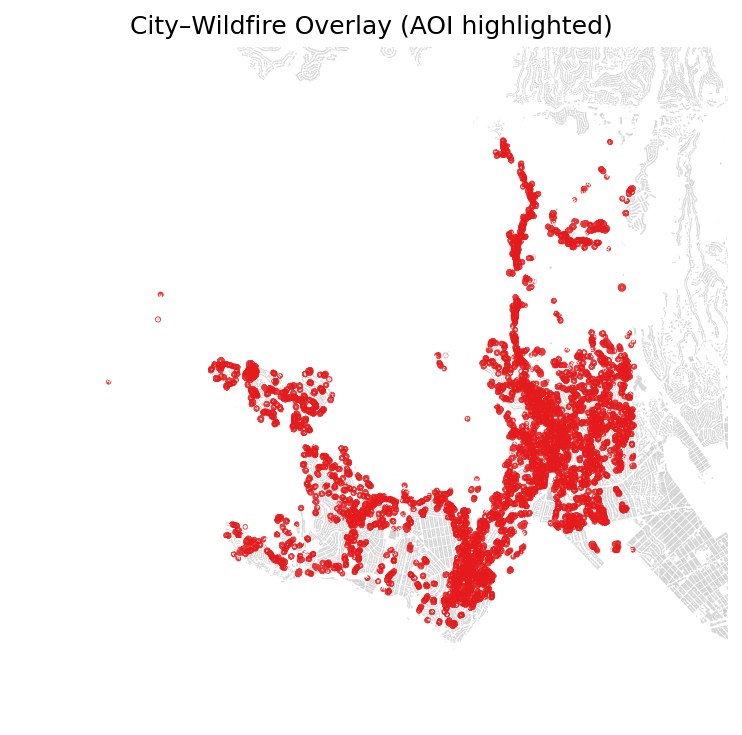

In [1]:
# -*- coding: utf-8 -*-
# Overlay map: city buildings (gray) + fire exposure AOI (orange fill, red outline)

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape
from shapely.ops import unary_union
import numpy as np
from pathlib import Path

# Optional: build AOI from fire raster (set to None to skip)
USE_FIRE_RASTER = True   # set False to use Vector-only AOI
FL_THRESHOLD = 2.0       # flame length threshold (m) used to delineate AOI if raster is used

# ---- Paths (edit to your files) ----
WIF = Path(r"C:/Users/10981/Desktop/WIF")
CITY_GPKG = WIF / "buildings_clip.gpkg"              # big city buildings (layer name 'bldg')
CITY_LAYER = "bldg"

# Option 1: AOI from fire raster
FL_RASTER = WIF / "flammmap_geotiff/aligned/FlameLength_aligned.tif"   # change to your flame length raster

# Option 2: AOI from buildings_with_fire_values (if no raster)
B_EXPO_GPKG = WIF / "buildings_with_fire_values.gpkg"  # layer 'houses'
B_EXPO_LAYER = "houses"

# ---- Helper: polygonize raster > threshold into a single AOI polygon ----
def aoi_from_raster(raster_path, threshold):
    import rasterio
    from rasterio.features import shapes
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(float)
        arr[arr==src.nodata] = np.nan
        mask = np.isfinite(arr) & (arr >= threshold)
        if mask.sum() == 0:
            return None
        # polygonize
        results = shapes(mask.astype("uint8"), mask=mask, transform=src.transform)
        geoms = [shape(geom) for geom, val in results if val == 1]
    if not geoms:
        return None
    # dissolve to single polygon (can buffer to smooth)
    poly = unary_union(geoms).buffer(0)
    return gpd.GeoDataFrame(geometry=[poly], crs=src.crs)

# ---- Helper: polygonize from exposed buildings (vector-only) ----
def aoi_from_buildings_exposure(gpkg, layer):
    g = gpd.read_file(gpkg, layer=layer)
    # use buildings that have any FL value (or you can filter by fl_max > x)
    if "fl_max" in g.columns:
        g = g[np.isfinite(g["fl_max"])]
    if g.empty:
        return None
    poly = unary_union(g.geometry).buffer(0)
    return gpd.GeoDataFrame(geometry=[poly], crs=g.crs)

# ---- Build AOI ----
aoi = None
if USE_FIRE_RASTER and FL_RASTER.exists():
    aoi = aoi_from_raster(FL_RASTER, FL_THRESHOLD)

if aoi is None and B_EXPO_GPKG.exists():
    aoi = aoi_from_buildings_exposure(B_EXPO_GPKG, B_EXPO_LAYER)

if aoi is None:
    raise RuntimeError("AOI could not be derived. Check paths or thresholds.")

# ---- Load city layer and align CRS ----
city = gpd.read_file(CITY_GPKG, layer=CITY_LAYER)
if city.crs != aoi.crs:
    city = city.to_crs(aoi.crs)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

# city baseline (light gray)
city.plot(ax=ax, color="#bfbfbf", edgecolor="#bfbfbf", linewidth=0.1, alpha=0.6)

# fire AOI (orange fill + red outline)
aoi.plot(ax=ax, facecolor="#fdae6b", edgecolor="#e41a1c", linewidth=2.5, alpha=0.85)

# optional: zoom to AOI with some padding
pad = 2000  # in projected units; reduce/increase if needed
minx, miny, maxx, maxy = aoi.total_bounds
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_axis_off()
ax.set_title("City–Wildfire Overlay (AOI highlighted)", fontsize=12)
plt.tight_layout()
plt.show()


Saved: C:\Users\10981\Desktop\WIF\city_buildings_basemap.png


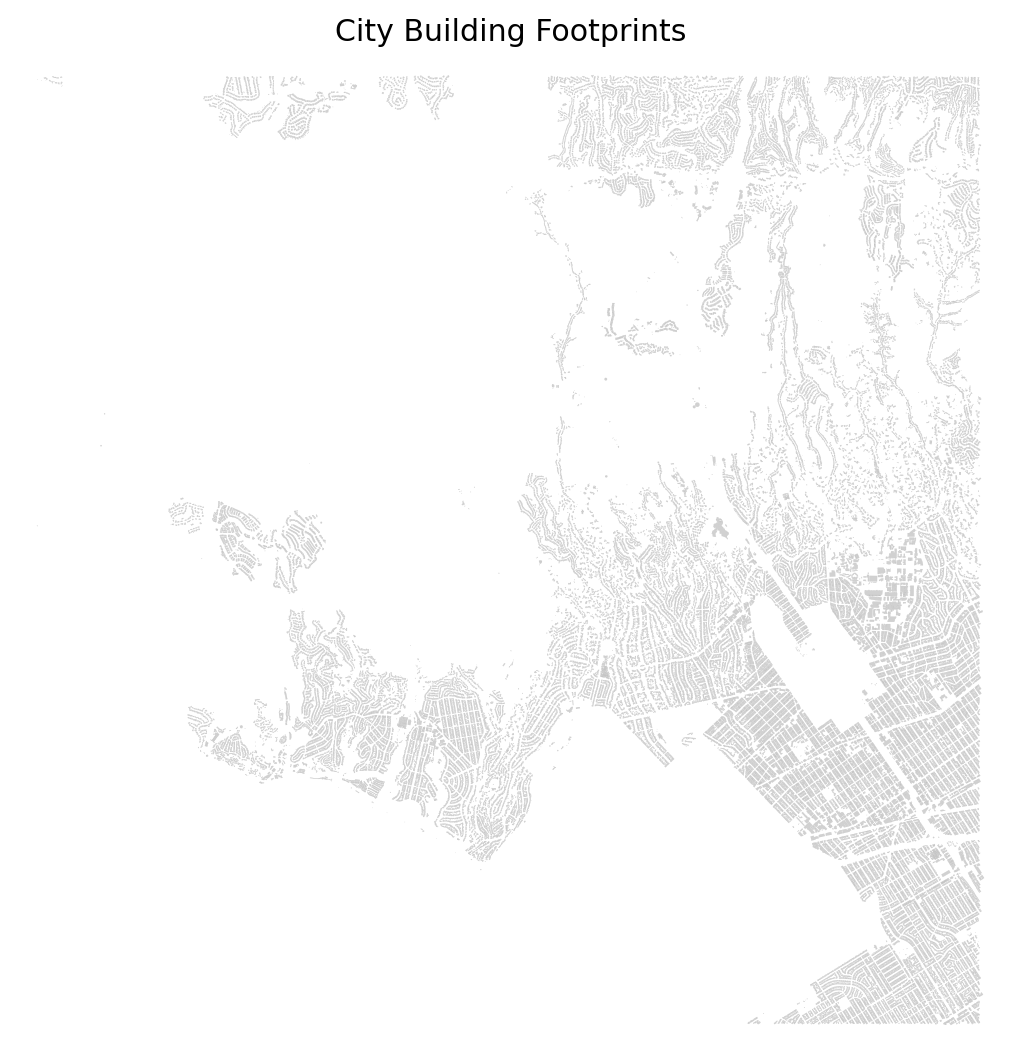

In [2]:
# -*- coding: utf-8 -*-
# Pure building basemap (no fire overlay)

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Paths (edit) ----
WIF = Path(r"C:/Users/10981/Desktop/WIF")
CITY_GPKG = WIF / "buildings_clip.gpkg"   # your city layer
CITY_LAYER = "bldg"                       # layer name in gpkg

# Optional: zoom to a bounding box (minx, miny, maxx, maxy) in the layer CRS
ZOOM_BBOX = None           # e.g., ( -13100000, 4000000, -13000000, 4100000 )  or None for full extent
SAVE_PNG  = WIF / "city_buildings_basemap.png"  # set to None if you don't want to save

# Speed options
USE_CENTROIDS = False      # True -> plot centroids instead of polygons (faster on huge data)
MAX_PLOTS     = None       # e.g., 300000 to limit number for speed; None = all

# ---- Load ----
g = gpd.read_file(CITY_GPKG, layer=CITY_LAYER)

# Optional downsample for speed
if isinstance(MAX_PLOTS, int) and len(g) > MAX_PLOTS:
    g = g.sample(MAX_PLOTS, random_state=42)

# Optional: centroids
g_plot = g.copy()
if USE_CENTROIDS:
    g_plot["geometry"] = g_plot.geometry.centroid

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6), dpi=180)
g_plot.plot(ax=ax, color="#cfcfcf", edgecolor="#bfbfbf", linewidth=0.08, alpha=0.95)

# Zoom if bbox provided
if ZOOM_BBOX is not None:
    minx, miny, maxx, maxy = ZOOM_BBOX
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
else:
    # small padding around full extent
    minx, miny, maxx, maxy = g_plot.total_bounds
    pad_x = (maxx - minx) * 0.02
    pad_y = (maxy - miny) * 0.02
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

ax.set_axis_off()
ax.set_title("City Building Footprints", fontsize=12)
plt.tight_layout()

# Save (optional)
if SAVE_PNG:
    plt.savefig(SAVE_PNG, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved: {SAVE_PNG}")

plt.show()


In [4]:
# -*- coding: utf-8 -*-
# Looser damage classification (percentile-based) + 4-color map
# Inputs:  C:/Users/10981/Desktop/WIF/buildings_with_fire_values.gpkg  (layer 'houses')
# Uses columns: fl_max, fli_max
# Outputs: buildings_damage_loose.gpkg, damage_loose_summary.csv, damage_loose_map.png

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ---------------- Paths ----------------
WIF = Path(r"C:/Users/10981/Desktop/WIF")
IN_GPKG   = WIF / "buildings_with_fire_values.gpkg"
LAYER_IN  = "houses"

OUT_GPKG  = WIF / "buildings_damage_loose.gpkg"
LAYER_OUT = "houses_damage"
OUT_SUM   = WIF / "damage_loose_summary.csv"
OUT_PNG   = WIF / "damage_loose_map.png"

# ---------------- Targets & knobs ----------------
# Target shares (approximate) to boost Minor/Major/Destroyed
TARGET_MINOR = 0.20   # >= 20% Minor
TARGET_MAJOR = 0.10   # >= 10% Major
TARGET_DEST  = 0.04   # >=  4% Destroyed

# Escalation by Fireline Intensity (lower than before to be more sensitive)
FLI_T2 = 1200   # raise to at least Major
FLI_T3 = 2500   # raise to Destroyed

# Which metrics to use
USE_FL_COL  = "fl_max"
USE_FLI_COL = "fli_max"

# 4-class color map
COLOR_MAP = {
    "None":      "#E09509",  # pale beige
    "Minor":     "#CE6815",  # light orange
    "Major":     "#B33A11",  # orange-red
    "Destroyed": "#E40A27"   # red
}

def percentile_thresholds(vals, t_minor, t_major, t_dest):
    """Compute FL thresholds (T1,T2,T3) using upper-tail percentiles so shares ~ targets."""
    s = pd.Series(vals).replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s >= 0]
    if s.empty:
        return np.nan, np.nan, np.nan
    # For desired shares p, use quantiles at (1-p)
    T1 = float(np.percentile(s, (1 - t_minor) * 100))
    T2 = float(np.percentile(s, (1 - t_major) * 100))
    T3 = float(np.percentile(s, (1 - t_dest)  * 100))
    # enforce monotonicity
    T2 = max(T2, T1)
    T3 = max(T3, T2)
    return T1, T2, T3

def classify(fl_val, fli_val, T1, T2, T3):
    """Return class (0..3) and text based on FL, escalated by FLI."""
    lvl = 0
    if np.isfinite(fl_val):
        if fl_val >= T3:      lvl = 3
        elif fl_val >= T2:    lvl = 2
        elif fl_val >= T1:    lvl = 1
        else:                 lvl = 0
    if np.isfinite(fli_val):
        if fli_val >= FLI_T3: lvl = max(lvl, 3)
        elif fli_val >= FLI_T2: lvl = max(lvl, 2)
    txt = {0:"None", 1:"Minor", 2:"Major", 3:"Destroyed"}[lvl]
    return lvl, txt

def plot_map(gdf, out_png, use_centroids=False, figsize=(10,10)):
    """Plot 4-color damage map."""
    g_plot = gdf.copy()
    if use_centroids:
        g_plot["geometry"] = g_plot.geometry.centroid

    order = ["None","Minor","Major","Destroyed"]
    fig, ax = plt.subplots(figsize=figsize, dpi=180)
    for k in order:
        sub = g_plot[g_plot["damage_txt"] == k]
        if not sub.empty:
            sub.plot(ax=ax, color=COLOR_MAP[k], linewidth=0, alpha=0.95)
    ax.set_axis_off()
    ax.set_title("Building Damage Map (Looser thresholds)", fontsize=13)
    handles = [Patch(facecolor=COLOR_MAP[k], label=k) for k in order]
    ax.legend(handles=handles, title="Damage Class", loc="lower left", frameon=True)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)

def main():
    g = gpd.read_file(IN_GPKG, layer=LAYER_IN)
    if USE_FL_COL not in g.columns or USE_FLI_COL not in g.columns:
        raise ValueError("Missing columns fl_max/fli_max in input.")

    # ---- compute looser FL thresholds from percentiles
    T1, T2, T3 = percentile_thresholds(g[USE_FL_COL], TARGET_MINOR, TARGET_MAJOR, TARGET_DEST)
    print(f"Computed thresholds: FL_T1={T1:.3f}, FL_T2={T2:.3f}, FL_T3={T3:.3f}; "
          f"FLI_T2={FLI_T2}, FLI_T3={FLI_T3}")

    # ---- classify
    cls, txt = [], []
    for fl, fli in zip(g[USE_FL_COL].to_numpy(), g[USE_FLI_COL].to_numpy()):
        c, t = classify(fl, fli, T1, T2, T3)
        cls.append(c); txt.append(t)
    g["damage_cls"] = cls
    g["damage_txt"] = txt

    # ---- summary
    order = ["None","Minor","Major","Destroyed"]
    dist = g["damage_txt"].value_counts().reindex(order, fill_value=0)
    pct  = (dist / len(g) * 100).round(2)
    summary = pd.DataFrame({"count": dist, "percent": pct})
    print("\n=== New distribution (looser) ===")
    print(summary)
    summary.to_csv(OUT_SUM, index=True, encoding="utf-8")

    # ---- save layer
    g.to_file(OUT_GPKG, layer=LAYER_OUT, driver="GPKG")
    print(f"\nSaved: {OUT_GPKG} (layer={LAYER_OUT})")
    print(f"Saved summary: {OUT_SUM}")

    # ---- map
    plot_map(g, OUT_PNG, use_centroids=False)
    print(f"Saved map: {OUT_PNG}")

if __name__ == "__main__":
    main()


Computed thresholds: FL_T1=3.944, FL_T2=5.917, FL_T3=6.161; FLI_T2=1200, FLI_T3=2500

=== New distribution (looser) ===
            count  percent
damage_txt                
None        64460    98.88
Minor         363     0.56
Major         211     0.32
Destroyed     158     0.24

Saved: C:\Users\10981\Desktop\WIF\buildings_damage_loose.gpkg (layer=houses_damage)
Saved summary: C:\Users\10981\Desktop\WIF\damage_loose_summary.csv
Saved map: C:\Users\10981\Desktop\WIF\damage_loose_map.png


In [6]:
# -*- coding: utf-8 -*-
# Robust combined score + target-share quantile cut
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

# ---- Paths ----
WIF = Path(r"C:/Users/10981/Desktop/WIF")
IN_GPKG   = WIF / "buildings_with_fire_values.gpkg"
LAYER_IN  = "houses"
OUT_GPKG  = WIF / "buildings_damage_quantile.gpkg"
LAYER_OUT = "houses_damage"
OUT_SUM   = WIF / "damage_quantile_summary.csv"
OUT_PNG   = WIF / "damage_quantile_map.png"

# ---- Target shares (you can tweak) ----
SHARE_DEST  = 0.04   # top 4% -> Destroyed
SHARE_MAJOR = 0.10   # next 10% -> Major
SHARE_MINOR = 0.20   # next 20% -> Minor
# remainder -> None

# ---- Which columns to use ----
FL_COL  = "fl_max"     # fallback: try "fl_mean" if max is degenerate
FLI_COL = "fli_max"    # fallback: "fli_mean"

# ---- Colors ----
COLOR_MAP = {
    "None":      "#EB8807D5",
    "Minor":     "#EB4314",
    "Major":     "#B43409",
    "Destroyed": "#510A13"
}

def robust_scale(x):
    """Robust z-score using median and IQR (avoid exploding due to outliers)."""
    x = pd.to_numeric(x, errors="coerce").astype(float)
    med = np.nanmedian(x)
    iqr = np.nanpercentile(x, 75) - np.nanpercentile(x, 25)
    if iqr <= 0 or not np.isfinite(iqr):
        iqr = np.nanstd(x) if np.nanstd(x) > 0 else 1.0
    z = (x - med) / iqr
    return z

def main():
    g = gpd.read_file(IN_GPKG, layer=LAYER_IN)
    # Build a combined score S; weights can be tuned
    # If FL is mostly zeros, FLI will dominate; otherwise两者共同起作用
    z_fl  = robust_scale(g.get(FL_COL, np.nan))
    z_fli = robust_scale(g.get(FLI_COL, np.nan))

    # Combined score: a*FL + b*sqrt(FLI) (use z-scores to normalize)
    # Try stronger weight on FL first; if诊断显示FL无效，可把 a 降低、b 提高
    a, b = 1.0, 1.0
    S = a * z_fl + b * z_fli

    # Handle NaNs: set to very low so they end up in "None"
    S = S.fillna(S.min() - 1)

    n = len(S)
    # Compute exact cut indices by sorted rank (to hit target shares)
    k_dest  = max(1, int(np.floor(n * SHARE_DEST)))
    k_major = max(1, int(np.floor(n * (SHARE_DEST + SHARE_MAJOR))))
    k_minor = max(1, int(np.floor(n * (SHARE_DEST + SHARE_MAJOR + SHARE_MINOR))))

    # Sort score descending
    order = np.argsort(-S.values)
    cls = np.zeros(n, dtype=int)  # 0 None, 1 Minor, 2 Major, 3 Destroyed
    cls[order[:k_dest]] = 3
    cls[order[k_dest:k_major]] = 2
    cls[order[k_major:k_minor]] = 1

    txt = pd.Series(cls).map({0:"None",1:"Minor",2:"Major",3:"Destroyed"})
    g["damage_cls"] = cls
    g["damage_txt"] = txt

    # Summary
    dist = g["damage_txt"].value_counts().reindex(["None","Minor","Major","Destroyed"], fill_value=0)
    pct  = (dist / n * 100).round(2)
    summary = pd.DataFrame({"count": dist, "percent": pct})
    print("\n=== Quantile-based distribution ===")
    print(summary)
    summary.to_csv(OUT_SUM, index=True, encoding="utf-8")

    # Save layer
    g.to_file(OUT_GPKG, layer=LAYER_OUT, driver="GPKG")
    print(f"\nSaved: {OUT_GPKG} (layer={LAYER_OUT})")
    print(f"Saved summary: {OUT_SUM}")

    # Plot map
    fig, ax = plt.subplots(figsize=(10,10), dpi=180)
    for k in ["None","Minor","Major","Destroyed"]:
        sub = g[g["damage_txt"] == k]
        if not sub.empty:
            sub.plot(ax=ax, color=COLOR_MAP[k], linewidth=0, alpha=0.95)
    ax.set_axis_off()
    ax.set_title("Building Damage Map (Quantile-based sensitive)", fontsize=13)
    handles = [Patch(facecolor=COLOR_MAP[k], label=k) for k in ["None","Minor","Major","Destroyed"]]
    ax.legend(handles=handles, title="Damage Class", loc="lower left", frameon=True)
    plt.tight_layout()
    plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"Saved map: {OUT_PNG}")

if __name__ == "__main__":
    from matplotlib.patches import Patch
    main()



=== Quantile-based distribution ===
            count  percent
damage_txt                
None        43027     66.0
Minor       13039     20.0
Major        6519     10.0
Destroyed    2607      4.0

Saved: C:\Users\10981\Desktop\WIF\buildings_damage_quantile.gpkg (layer=houses_damage)
Saved summary: C:\Users\10981\Desktop\WIF\damage_quantile_summary.csv
Saved map: C:\Users\10981\Desktop\WIF\damage_quantile_map.png



=== Forced-share distribution (target 87% Destroyed) ===
            count  percent
damage_txt                
None         1696      2.6
Minor        2542      3.9
Major        4237      6.5
Destroyed   56717     87.0


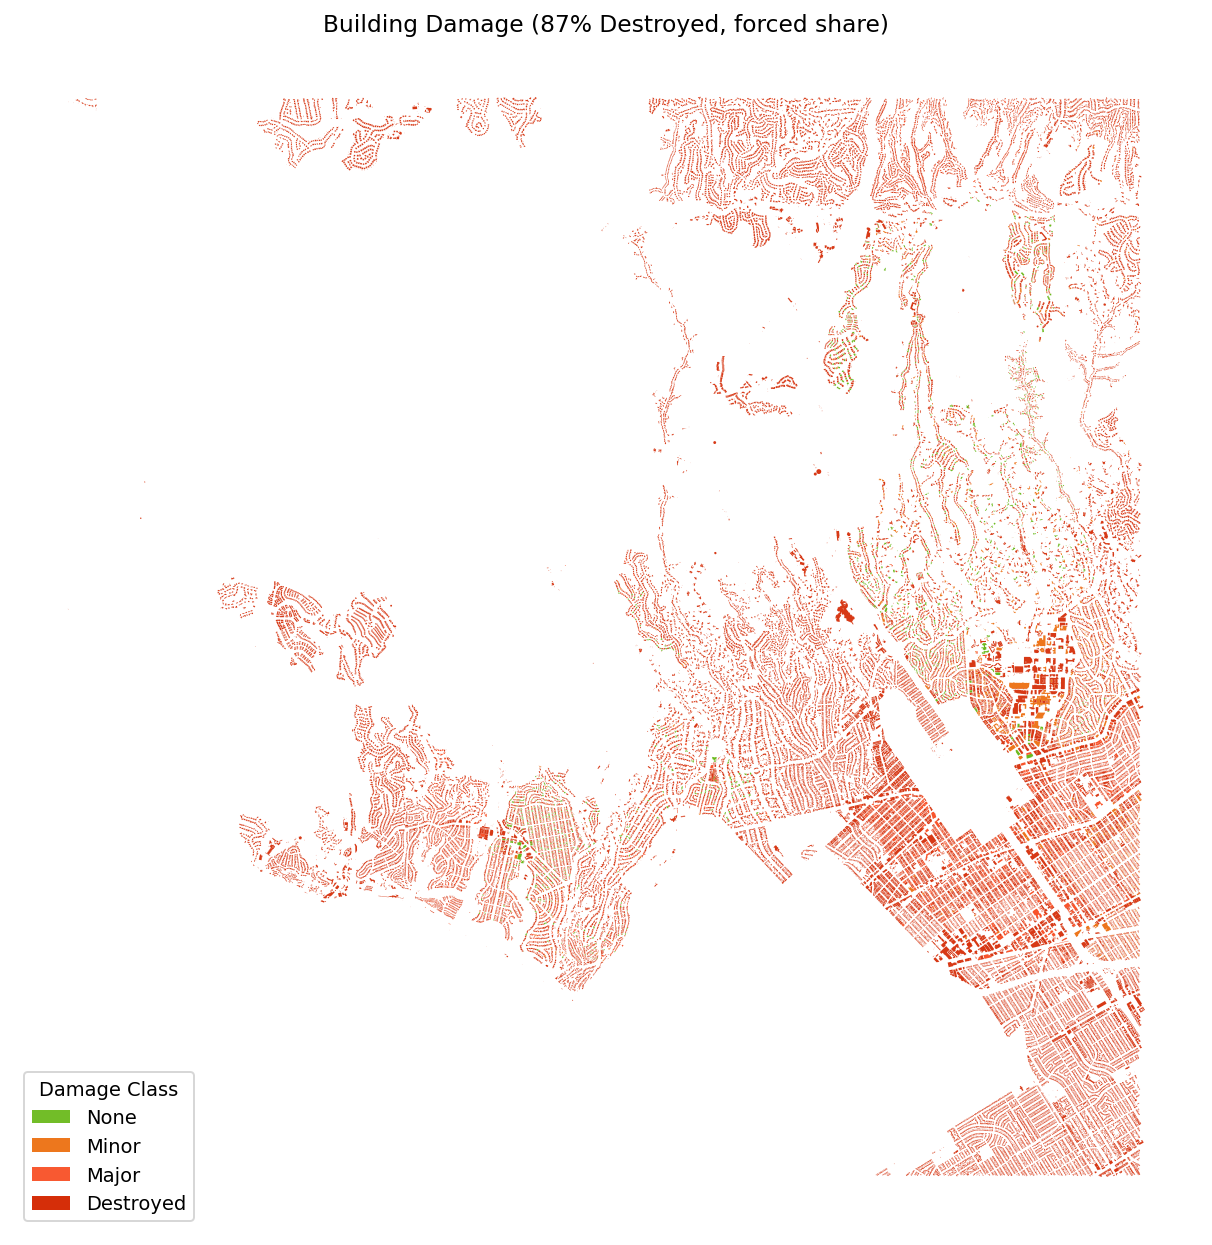

In [4]:
# -*- coding: utf-8 -*-
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ========= Inputs =========
IN_GPKG  = r"C:/Users/10981/Desktop/WIF/buildings_with_fire_values.gpkg"
LAYER_IN = "houses"

# Columns for fire metrics
FL_COL  = "fl_max"
FLI_COL = "fli_max"

# Weighted score parameters
A_WEIGHT = 2.0   # weight for fl
B_WEIGHT = 1.0   # weight for fli

# Target shares
SHARE_DEST  = 0.87   # 87% → Destroyed
SHARE_MAJOR = 0.065  # 6.5% → Major
SHARE_MINOR = 0.039  # 3.9% → Minor
# remainder = 1 - (0.87+0.065+0.039) ≈ 0.026 → None

# Plot colors
DRAW_MAP = True
COLOR_MAP = {
    "None":      "#63B611E7",
    "Minor":     "#EC6F10F1",
    "Major":     "#F84B20EC",
    "Destroyed": "#D52E09"
}

# ========= Functions =========
def robust_scale(x: pd.Series) -> pd.Series:
    """Robust z-score using median and IQR; fallback to std if IQR<=0."""
    x = pd.to_numeric(x, errors="coerce").astype(float)
    med = np.nanmedian(x)
    q75, q25 = np.nanpercentile(x, 75), np.nanpercentile(x, 25)
    iqr = q75 - q25
    if not np.isfinite(iqr) or iqr <= 0:
        sd = np.nanstd(x)
        iqr = sd if (sd and sd > 0) else 1.0
    return (x - med) / iqr

# ========= Main =========
g = gpd.read_file(IN_GPKG, layer=LAYER_IN)

# Build weighted score
z_fl  = robust_scale(g.get(FL_COL, np.nan))
z_fli = robust_scale(g.get(FLI_COL, np.nan))
S = A_WEIGHT * z_fl + B_WEIGHT * z_fli

# Handle NaNs → push to the bottom
fill_val = np.nanmin(S.values.astype(float)) - 1 if np.any(~np.isnan(S.values)) else -1e9
S = S.fillna(fill_val)

# Sort by score
n = len(S)
order = np.argsort(-S.values)

# Exact counts
n_dest  = int(round(n * SHARE_DEST))
n_major = int(round(n * SHARE_MAJOR))
n_minor = int(round(n * SHARE_MINOR))
n_none  = n - (n_dest + n_major + n_minor)

# Assign classes
cls = np.zeros(n, dtype=int)  # 0=None, 1=Minor, 2=Major, 3=Destroyed
cls[order[:n_dest]] = 3
cls[order[n_dest:n_dest + n_major]] = 2
cls[order[n_dest + n_major:n_dest + n_major + n_minor]] = 1
# rest are 0=None

g["damage_cls"] = cls
g["damage_txt"] = pd.Series(cls).map({0:"None",1:"Minor",2:"Major",3:"Destroyed"})

# Summary
dist = g["damage_txt"].value_counts().reindex(["None","Minor","Major","Destroyed"], fill_value=0)
pct  = (dist / n * 100).round(1)
summary = pd.DataFrame({"count": dist, "percent": pct})
print("\n=== Forced-share distribution (target 87% Destroyed) ===")
print(summary)

# Plot in memory
if DRAW_MAP:
    fig, ax = plt.subplots(figsize=(9,9), dpi=140)
    for k in ["None","Minor","Major","Destroyed"]:
        sub = g[g["damage_txt"] == k]
        if not sub.empty:
            sub.plot(ax=ax, color=COLOR_MAP[k], linewidth=0, alpha=0.95)
    ax.set_axis_off()
    ax.set_title("Building Damage (87% Destroyed, forced share)", fontsize=12)
    handles = [Patch(facecolor=COLOR_MAP[k], label=k) for k in ["None","Minor","Major","Destroyed"]]
    ax.legend(handles=handles, title="Damage Class", loc="lower left", frameon=True)
    plt.tight_layout()
    plt.show()
